# A Guide to Querying GridDB Timeseries Containers with TQL and Python

## Introduction

In today's world, handling time series data in a quick and efficient way is crucial for several high-impact applications, such as IoT, industrial monitoring, and research. GridDB, a highly scalable and robust NoSQL database, is specifically designed for such workloads. GridDB offers native support for specialized data objects for storing time series data. These are called timeseries containers and help with fast and reliable data ingestion.

In this blog, we'll use the Intel Lab sensor data to demonstrate how to store, query, and analyze this data using GridDB’s TQL (Time-series Query Language) and Python. We will also extract insights efficiently and see how GridDB makes working with high-volume timeseries data user-friendly and intuitive. Let's dive right in.

In [1]:
from IPython.display import display, HTML

image_path = 'round-icons-otzESK2sBG4-unsplash.png'
width = 500

display(HTML(f"""
<div style="text-align: center;">
    <img src="{image_path}" style="width:80%; max-width:500px;"><br>
    <span style="font-size:1.2em; color: #555;">
        Illustration by 
        <a href="https://unsplash.com/@roundicons?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Round Icons</a> 
        on 
        <a href="https://unsplash.com/illustrations/a-computer-chip-with-a-red-yellow-and-green-color-scheme-otzESK2sBG4?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
    </span>
</div>
"""))

## Installing pre-requsities - Libraries

In [ ]:
#File system and I/O operations
import os
from io import BytesIO
# Data manipulation 
import pandas as pd
import numpy as np
from IPython.display import Image

# Time functions
import math
import time
from datetime import datetime, timedelta

# Data Gathering
import requests
import zipfile

#Encoding and Serialization
import base64
import json

#Debugging
import http
http.client.HTTPConnection.debuglevel = 0

#Visualization Libraries
import plotly.graph_objects as go
import plotly.express as px
import pycountry
import kaleido

## About the Intel Lab Dataset & Attribution

The Intel Lab dataset contains data collected from 54 sensors deployed in the Intel Berkeley Research lab between February 28th and April 5th, 2004. The sensors collected humidity, temperature, voltage and light. While the floor plan of the sensors's placement has been shared in an image; the coordinates have also been provided in a flat file along with the dataset. The data is available in a compressed format as a '.gz' file. The data has more than 2 Million rows.

The Intel Lab Data was collected and made available through the efforts of Peter Bodik, Wei Hong, Carlos Guestrin, Sam Madden, Mark Paskin, and Romain Thibaux, with support from Intel Berkeley and the TinyOS team. Special thanks to Mark Paskin for aggregating connectivity data and generating the network layout, and to Sam Madden and Wei Hong for developing TinyDB and logging infrastructure. This dataset is hosted by MIT CSAIL and was last modified by Samuel Madden on June 2, 2004.

## Accessing the Dataset

To download the Intel Lab Dataset, access the URL - https://db.csail.mit.edu/labdata/labdata.html. Access the file having the location co-ordinates (x and y-coordinates) of the sensors (mote_locs.txt), and the file having the sensor readings (data.txt.gz). Extract the compressed file to access the data.

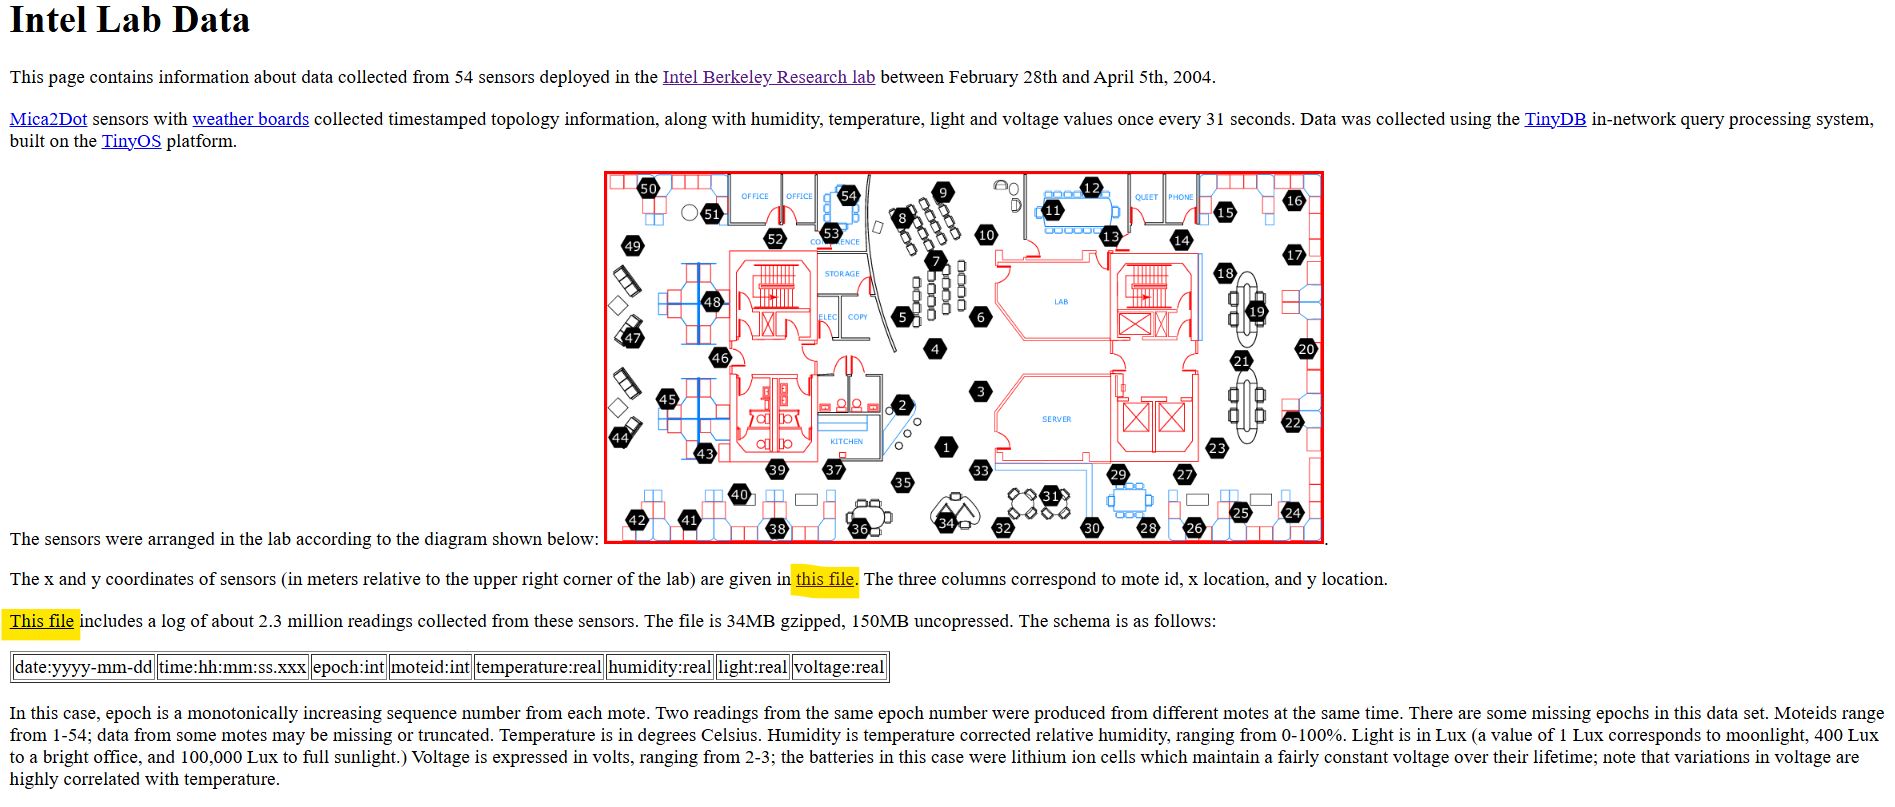

In [3]:
##Specify the path to your image file
image_path = 'Dataset_Download.png'

width = 1700

## Display the image
Image(filename=image_path, width=width)

## Dataset Download Instructions

To download the Intel Lab Dataset:
In the <a href = "https://db.csail.mit.edu/labdata/labdata.html"> Dataset page </a> shared above,
- Click on the link labeled “This file” to download the compressed sensor readings file:
- data.txt.gz will begin downloading automatically.
- Also download the sensor location file:
- Click on mote_locs.txt to get the sensor coordinates.
- Decompress the .gz file using your preferred tool (e.g., gunzip, 7-Zip, or Python’s gzip module).

## Mapping Motes to Floor Plan Zones
Based on the coordinate system and floor plan shared in the dataset URL, below is an approximate mapping of the motes to the rooms or zones. We will use this information to come up with possible explanations for anomalies.

<table border="1" cellpadding="6" cellspacing="0">
  <thead>
    <tr>
      <th>Mote ID</th>
      <th>X (meters)</th>
      <th>Y (meters)</th>
      <th>Approximate Room/Zone</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>1</td><td>1.0</td><td>1.0</td><td>STORAGE</td></tr>
    <tr><td>2</td><td>2.0</td><td>1.5</td><td>STORAGE</td></tr>
    <tr><td>3</td><td>3.0</td><td>2.0</td><td>LAB</td></tr>
    <tr><td>4</td><td>4.0</td><td>2.5</td><td>LAB</td></tr>
    <tr><td>5</td><td>5.0</td><td>3.0</td><td>LAB</td></tr>
    <tr><td>6</td><td>6.0</td><td>3.5</td><td>LAB</td></tr>
    <tr><td>7</td><td>7.0</td><td>4.0</td><td>LAB</td></tr>
    <tr><td>8</td><td>8.0</td><td>4.5</td><td>LAB</td></tr>
    <tr><td>9</td><td>9.0</td><td>5.0</td><td>LAB</td></tr>
    <tr><td>10</td><td>10.0</td><td>5.5</td><td>LAB</td></tr>
    <tr><td>11</td><td>11.0</td><td>6.0</td><td>CONF.</td></tr>
    <tr><td>12</td><td>12.0</td><td>6.5</td><td>CONF.</td></tr>
    <tr><td>13</td><td>13.0</td><td>7.0</td><td>CONF.</td></tr>
    <tr><td>14</td><td>14.0</td><td>7.5</td><td>QUIET PHONE</td></tr>
    <tr><td>15</td><td>15.0</td><td>8.0</td><td>QUIET PHONE</td></tr>
    <tr><td>16</td><td>16.0</td><td>8.5</td><td>SERVER</td></tr>
    <tr><td>17</td><td>17.0</td><td>9.0</td><td>SERVER</td></tr>
    <tr><td>18</td><td>18.0</td><td>9.5</td><td>CONF.</td></tr>
    <tr><td>19</td><td>19.0</td><td>10.0</td><td>CONF.</td></tr>
    <tr><td>20</td><td>20.0</td><td>10.5</td><td>CONF.</td></tr>
    <tr><td>21</td><td>21.0</td><td>11.0</td><td>OFFICE</td></tr>
    <tr><td>22</td><td>22.0</td><td>11.5</td><td>OFFICE</td></tr>
    <tr><td>23</td><td>23.0</td><td>12.0</td><td>OFFICE</td></tr>
    <tr><td>24</td><td>24.0</td><td>12.5</td><td>COPY</td></tr>
    <tr><td>25</td><td>25.0</td><td>13.0</td><td>COPY</td></tr>
    <tr><td>26</td><td>26.0</td><td>13.5</td><td>ELEC.</td></tr>
    <tr><td>27</td><td>27.0</td><td>14.0</td><td>ELEC.</td></tr>
    <tr><td>28</td><td>28.0</td><td>14.5</td><td>ELEC.</td></tr>
    <tr><td>29</td><td>29.0</td><td>15.0</td><td>OFFICE</td></tr>
    <tr><td>30</td><td>30.0</td><td>15.5</td><td>OFFICE</td></tr>
    <!-- Continue similarly for motes 31–54 -->
  </tbody>
</table>

In the next section, we load the datasets into DataFrames.

## Loading Datasets into Python Dataframes

In [4]:
folder_name = "data.txt"
file_name = "data.txt"

# Building the file path
file_path = os.path.join(os.getcwd(), folder_name, file_name)

# Reading the space-separated file
sensor_data_df = pd.read_csv(file_path, 
                 sep=r"\s+",  # any whitespace
                 header=None,  # no header in file
                 names=["date", "time", "epoch", "moteid", "temperature", "humidity", "light", "voltage"])

sensor_data_df['timestamp'] = pd.to_datetime(
    sensor_data_df['date'] + ' ' + sensor_data_df['time'],  # space between date & time
    utc=True,       # optional, converts to UTC
    errors='coerce',  # will turn unparseable rows into NaT
    format='mixed'    # infers format row by row
)

# Missing Value Imputation
sensor_data_df['moteid'] = sensor_data_df['moteid'].fillna(-1).astype(int)

# Deleting redundant columns
sensor_data_df = sensor_data_df.drop(columns=['date', 'time'])

# Moving 'timestamp' to the first column
cols = ['timestamp'] + [col for col in sensor_data_df.columns if col != 'timestamp']
sensor_data_df = sensor_data_df[cols]
sensor_data_df['moteid'] = sensor_data_df['moteid'].astype(int) 

#YYYY-MM-DDThh:mm:ss.SSSZ
# Converting the timestamp value to ISO 8601 format
sensor_data_df['timestamp'] = sensor_data_df['timestamp'].dt.strftime('%Y-%m-%dT%H:%M:%S.%f')  # Format with microseconds
sensor_data_df['timestamp'] = sensor_data_df['timestamp'].str[:-3] + 'Z'  # Adjust to milliseconds and append 'Z'
sensor_data_df.head()

,timestamp,epoch,moteid,temperature,humidity,light,voltage
0,2004-03-31T03:38:15.757Z,2,1,122.1530,-3.91901,11.04,2.03397
1,2004-02-28T00:59:16.027Z,3,1,19.9884,37.09330,45.08,2.69964
2,2004-02-28T01:03:16.333Z,11,1,19.3024,38.46290,45.08,2.68742
3,2004-02-28T01:06:16.013Z,17,1,19.1652,38.80390,45.08,2.68742
4,2004-02-28T01:06:46.778Z,18,1,19.1750,38.83790,45.08,2.69964


In [5]:
# Saving the co-ordinates data into a file
mote_locs_df = pd.read_csv("mote_locs.txt",
                 sep=r"\s+",  # any whitespace
                 header=None,  # no header in file
                 names=["moteid", "x_location", "y_location"])


In [6]:
mote_locs_df.head()

,moteid,x_location,y_location
0,1,21.5,23
1,2,24.5,20
2,3,19.5,19
3,4,22.5,15
4,5,24.5,12


## Creating Containers

GridDB provides two types of Containers, namely Collections and TimeSeries. Collections are used to store lookup data, historic data, and transactional data that are not time-sensitive. Timeseries Containers are used to store time-sensitive data used in telemetry and sensors for IoT applications. Irrespective of the Container type, there are multiple options for container creation and data ingestion like the WebAPI, JayDeBeAPI, GridDB CE and official SDKs. In this blog, we use the WebAPI throughout. To learn more about each of the connection options, refer to the following resources - 
<ul>
<li> Community CLI for GridDB Cloud - <a href = "https://github.com/Imisrael/griddb-cloud-cli/blob/main/README.md"> griddb-cloud-cli </a></li>
<li> JayDeBeAPI - <a href = "https://griddb.net/en/blog/using-python-to-interface-with-griddb-via-jdbc-with-jaydebeapi/">JayDeBeAPI Guide </li>
<li> WebAPI - <a href = "https://griddb.org/docs/30_reference_api/18.md_reference_web_api/md_reference_web_api/">WebAPI Guide </a></li>
<li> Official SDK - <a href = "https://pypi.org/project/griddb-python/"> griddb-python Readme </a></li>
</ul>

To start with the container creation, set up the credentials. Note that GridDB expects base64 encoded credentials. We use the library base64 to do so. This is then passed to the header object.

In [ ]:
username = "xxx" # Provide your GridDB credentials here
password =   "xxx" # Provide your GridDB credentials here
credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()
#print(f"Encoded credentials: Basic {encoded_credentials}")

The header object consists of the below elements. Ensure that you have the correct base_url. The base URL can be obtained from GridDB cloud by navigating to the Clusters menu and clicking on 'Overview'. The base URL to be used is labelled 'GridDB WebAPI URL'.

In [13]:
#Construct an object to hold the request headers 
header_obj = {
    "Authorization": f"Basic {encoded_credentials}",  # Add encoded credentials here
    "Content-Type": "application/json",  # Optional; depends on API requirements
    "charset": "UTF-8",
    "User-Agent":"PostmanRuntime/7.29.0"
}

#Construct the base URL based on your GridDB cluster you'd like to connect to (ensure that you replace the placeholders in the URL below with the correct values that correspond to your GridDB instance)
#'https://[host]:[port]/griddb/v2/[clustername]/dbs/[database_name]'
base_url = 'https://cloud5197.griddb.com:443/griddb/v2/gs_clustermfcloud5197/dbs/aFsJLK8l/'

We then define two python functions to map pandas datatypes to the appropriate data type in GridDB. The 'generate_griddb_data_obj' function yields the container structure. We will be calling these functions in the http request for container creation. Refer to this <a href ="https://youtu.be/3eEQTiJORZo?si=6Xx35g8yTcHc8wLn"> GridDB tutorial </a> to learn more about container models.

In [7]:
def map_dtype_to_griddb(dtype):
    """
    Maps Pandas data types to GridDB data types.
    """
    if pd.api.types.is_integer_dtype(dtype):
        return "INTEGER"
    elif pd.api.types.is_float_dtype(dtype):
        return "DOUBLE"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOL"
    ##elif pd.api.types.is_datetime64_any_dtype(dtype):
        ##return "LONG"  # GridDB stores timestamps as LONG
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "TIMESTAMP"
    else:
        return "STRING"

In [8]:
def generate_griddb_data_obj(df, container_name="MyContainer", container_type="COLLECTION", rowkey=False):
    """
    Generates a GridDB container data object for API request.
    """
    columns = []
    for col in df.columns:
        griddb_type = map_dtype_to_griddb(df[col].dtype)
        columns.append({"name": col, "type": griddb_type})
    
    data_obj = {
        "container_name": container_name,
        "container_type": container_type,
        "rowkey": rowkey,
        "columns": columns
    }
    
    return data_obj

### Creating the Timeseries Container 'sensor_data'

In [ ]:
data_obj = generate_griddb_data_obj(sensor_data_df, container_name="sensor_data")

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)
x.text

### Creating the Collection Container 'mote_locations'

In [14]:
data_obj = generate_griddb_data_obj(mote_locs_df, container_name="mote_locations",container_type ="COLLECTION", rowkey=False)

#Set up the GridDB WebAPI URL
url = base_url + 'containers'

#Invoke the GridDB WebAPI with the headers and the request body
x = requests.post(url, json = data_obj, headers = header_obj)

## Loading the TimeSeries Container 'Sensor_data'

Loading the Containers is also known as Row Registration in GridDB. Refer to <a href = "https://griddb.org/docs/30_reference_api/18.md_reference_web_api/md_reference_web_api/"> this resource </a> to learn more.

In [ ]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/sensor_data/rows'
print(url)

In [27]:
batch_size = 5000
total_rows = len(sensor_data_df)
total_batches = math.ceil(total_rows / batch_size)

print(f"Starting ingestion of {total_rows:,} rows in {total_batches} batches of {batch_size} each...")
start_time = time.time()

for i in range(total_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, total_rows)
    batch_df = sensor_data_df.iloc[start_idx:end_idx]

    # Wrap in a dict with key "rows"
    #batch_json = json.dumps({"rows": json.loads(batch_df.to_json(orient='values'))})
    #batch_json = json.dumps(batch_df.to_json(orient='values'))
    batch_json = batch_df.to_json(orient='values')
    
    try:
        #print(url)
        #response = requests.put(url, headers=header_obj, data=batch_json)
        response = requests.put(url, headers=header_obj, data=batch_json)
        #print(batch_json)
        '''
        print(response.text)
        print(response)
        break
        '''
        elapsed = time.time() - start_time

        if response.status_code in [200, 201]:
            print(f" Batch {i+1}/{total_batches} | Rows {start_idx}-{end_idx-1} | "
                  f"Time elapsed: {elapsed:.1f}s")
        else:
            print(f" Batch {i+1}/{total_batches} FAILED "
                  f"(HTTP {response.status_code}) - {response.text[:150]}")

    except Exception as e:
        print(f" Batch {i+1}/{total_batches} ERROR: {e}")

print(f"\n Ingestion completed in {time.time() - start_time:.1f} seconds.")

Starting ingestion of 2,313,682 rows in 463 batches of 5000 each...
 Batch 1/463 | Rows 0-4999 | Time elapsed: 2.3s
 Batch 2/463 | Rows 5000-9999 | Time elapsed: 3.9s
 Batch 3/463 | Rows 10000-14999 | Time elapsed: 5.5s
 Batch 4/463 | Rows 15000-19999 | Time elapsed: 7.1s
 Batch 5/463 | Rows 20000-24999 | Time elapsed: 8.5s
 Batch 6/463 | Rows 25000-29999 | Time elapsed: 10.0s
 Batch 7/463 | Rows 30000-34999 | Time elapsed: 11.5s
 Batch 8/463 | Rows 35000-39999 | Time elapsed: 13.0s
 Batch 9/463 | Rows 40000-44999 | Time elapsed: 14.7s
 Batch 10/463 | Rows 45000-49999 | Time elapsed: 16.2s
 Batch 11/463 | Rows 50000-54999 | Time elapsed: 17.8s
 Batch 12/463 | Rows 55000-59999 | Time elapsed: 19.3s
 Batch 13/463 | Rows 60000-64999 | Time elapsed: 20.8s
 Batch 14/463 | Rows 65000-69999 | Time elapsed: 22.3s
 Batch 15/463 | Rows 70000-74999 | Time elapsed: 23.8s
 Batch 16/463 | Rows 75000-79999 | Time elapsed: 25.4s
 Batch 17/463 | Rows 80000-84999 | Time elapsed: 26.9s
 Batch 18/463 | Ro

## Loading the Collection Container 'mote_locations'

In [17]:
#Setup the URL to be used to invoke the GridDB WebAPI to register rows in the container created previously
url = base_url + 'containers/mote_locations/rows'
mote_locs_data = mote_locs_df.to_json(orient='values')
response = requests.put(url, headers=header_obj, data=mote_locs_data)

## GridDB TQL Wrapper for Query Processing

GridDB supports both SQL querying and TQL querying options for containers. While SQL is used to query collection containers, both SQL and TQL can be used to query timeseries containers. In this blog, we demonstrate the usage of TQL to query the timeseries container. We then leverage Python to handle some aspects of the post-processing. For example, we use Python to perform a join on the results of our TQL query to the data with the mote_locs_df.

Below are two functions we have created for processing the TQL query effectively using the WebAPI and Python. The function with the name 'tql_to_df(tql_response)' converts the JSON response from a GridDB TQL WebAPI query into a pandas DataFrame, using the column names and results provided.

The function named 'run_tql(query, container, auto_alias=True)' sends the TQL query to a GridDB container via the WebAPI, measures execution time, and converts the response to a DataFrame using the earlier function 'tql_to_df(tql_response)'.

In [19]:
def tql_to_df(tql_response):
    # Convert GridDB TQL WebAPI response to pandas DataFrame
    if not tql_response:
        return pd.DataFrame()
    
    resp = tql_response[0]  # usually one container per request
    columns = [col.get('name') for col in resp.get('columns', [])]
    results = resp.get('results', [])
    
    df = pd.DataFrame(results, columns=columns)
    return df

def run_tql(query, container, auto_alias=True):
    #Running a TQL query via WebAPI
    tql_url = f"{base_url}tql"
    headers = header_obj
    payload = [{"stmt": query, "name": container}]
    start = time.time()

    response = requests.post(tql_url, headers=headers, data=json.dumps(payload))
    elapsed = time.time() - start

    if response.status_code == 200:
        data = response.json()
        df = tql_to_df(data)
        
        # Auto-rename the aggregation column if needed
        if auto_alias and len(df.columns) == 1 and df.columns[0] == 'aggregationResult':
            # Try to extract the aggregation name from the query
            import re
            match = re.search(r'(?:SELECT\s+)(\w+)\((\w+)\)', query, re.IGNORECASE)
            if match:
                agg_func, col_name = match.groups()
                df.rename(columns={'aggregationResult': f"{agg_func.capitalize()}-{col_name.capitalize()}"}, inplace=True)
        
        print(f"Query ran in {elapsed:.3f}s | {len(df)} rows returned")
        return df, elapsed
    else:
        print(f"FAILED ({response.status_code}) - {response.text}\n")
        return pd.DataFrame(), elapsed

## Tracking Query Execution Times

The function 'run_tql' tracks query execution times. For demonstration purposes, we have encapsulated multiple query calls, one for each mote that is passed as an argument to the function. This is why you will see multiple print statements for the query execution times. Each execution time applies to a mote id that has been passed as an argument.

## Querying Data

### What are the time averages of the first ten Motes?

GridDB TQL supports a special kind of average called the Time Average. A Time Average (TIME_AVG) is basically a weighted average of temperatures over time. Imagine you have a thermometer that records your room's temperature at different times throughout the day. Sometimes it records every minute, and other times every hour. If you simply averaged the readings, a temperature that lasted an hour and one that lasted a minute would count the same. That wouldn’t be fair. TIME_AVG is a smarter version of the AVG function, which gives more importance to readings that lasted longer. If a temperature stays the same for a long time, it counts more. If a temperature was just a quick blip, it counts less. Refer to this <a href = "https://griddb.org/docs-en/manuals/GridDB_TQL_Reference.html#time_avgcolumn"> GridDB resource </a> to learn more about the TIME_AVG() function.

In [34]:
def get_time_avg_for_mote(mote_id, start_time, end_time):
    query = f"""
        SELECT TIME_AVG(temperature)
        WHERE moteid = {mote_id}
        AND TIMESTAMP('{start_time}') <= timestamp
        AND timestamp < TIMESTAMP('{end_time}')
    """
    df, elapsed = run_tql(query, container="sensor_data")
    if not df.empty:
        df["moteid"] = mote_id
    return df

In [53]:
motes = [1, 2, 3, 4, 5, 6,7,8,9,10]
start_time = "2004-03-01T00:00:00Z"
end_time = "2004-03-04T00:00:00Z"

results = []
for mote in motes:
    df = get_time_avg_for_mote(mote, start_time, end_time)
    if not df.empty:
        results.append(df)

# Combining results
Motes_time_averages_df = pd.concat(results, ignore_index=True)

Query ran in 1.011s | 1 rows returned
Query ran in 0.787s | 1 rows returned
Query ran in 0.719s | 1 rows returned
Query ran in 0.745s | 1 rows returned
Query ran in 0.722s | 1 rows returned
Query ran in 0.719s | 1 rows returned
Query ran in 0.798s | 1 rows returned
Query ran in 0.739s | 1 rows returned
Query ran in 0.735s | 1 rows returned
Query ran in 0.728s | 1 rows returned


In [54]:
Motes_time_averages_df = Motes_time_averages_df.sort_values(by="Time_avg-Temperature", ascending=False)
Motes_time_averages_df.head()

,Time_avg-Temperature,moteid
3,21.814175,4
2,21.694911,3
0,21.584323,1
8,21.506595,9
6,21.494475,7
1,21.425509,2
5,21.294827,6
9,21.257288,10
7,21.224919,8
4,2.383918,5


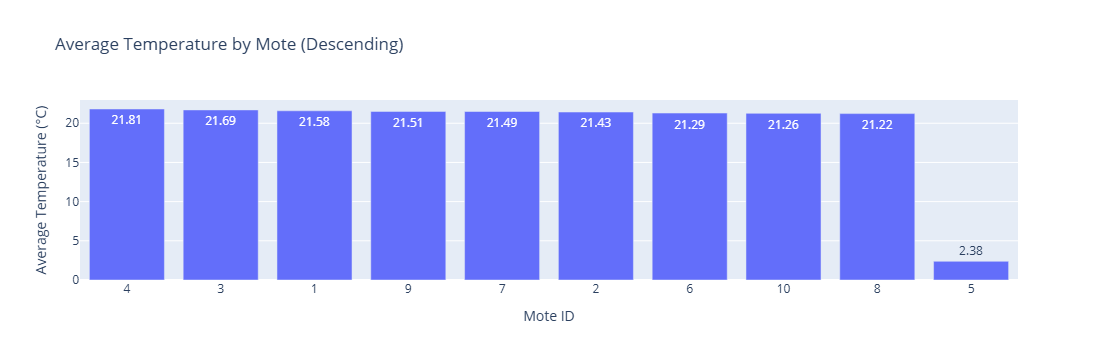

In [56]:
Motes_time_averages_df['moteid'] = Motes_time_averages_df['moteid'].astype(str)
mote_locs_df['moteid'] = mote_locs_df['moteid'].astype(str)
merged_df = pd.merge(Motes_time_averages_df, mote_locs_df, on='moteid', how='left')
Motes_time_averages_df["moteid"] = Motes_time_averages_df["moteid"].astype(str)  # ensure consistent type

fig = px.bar(
    Motes_time_averages_df,
    x="moteid",
    y="Time_avg-Temperature",
    title="Average Temperature by Mote (Descending)",
    labels={"moteid": "Mote ID", "Time_avg-Temperature": "Average Temperature (°C)"},
    text_auto=".2f",
    category_orders={"moteid": Motes_time_averages_df["moteid"].tolist()}  # <- this line forces plot order
)
fig.show()

<b> Insight(s): </b> We see that Mote 4 has the highest temperature reading of 21.81 and Mote 5 has the lowest temperature reading of 2.38. We can drill down further to analyse why Mote 5 seems to be recording a temperature completely different from the other motes. Let's compare the placement of the motes mentioned in the section titled [Mapping-Motes-to-Floor-Plan-Zones](#Mapping-Motes-to-Floor-Plan-Zones). Motes 1-4, 6–10 are all in LAB, OFFICE, or CONF zones. Being interior zones, they may be climate-controlled and also likely occupied. This is why they seem to have similar readings. On the other hand,  Mote 5 (the outlier with 2.38 degrees C), is in the STORAGE room. Storage rooms are typically unoccupied and are usually near an external wall or may have a cooler airflow. Hence, mote 5 may be showing a different reading. 
This confirms that placement is the dominant factor ie anomaies related to temperature.


## What does the spatial distribution of motes look like, and which mote recorded the highest temperature?

Here, we look at the maximum temperatures of motes using TQL, We then combine the readings using Python and plot them to understand better.

In [23]:
def get_max_temp_for_mote(mote_id, start_time, end_time):
    query = f"""
        SELECT MAX(temperature)
        WHERE
        temperature > 25
        AND moteid = {mote_id}
        AND TIMESTAMP('{start_time}') <= timestamp
        AND timestamp < TIMESTAMP('{end_time}')
    """
    df, elapsed = run_tql(query, container="sensor_data")
    if not df.empty:
        df["moteid"] = mote_id
    return df

In [24]:
motes = [1,2,3,4,5,6,8,10,12,13,14,15,16,17,18,19,20,22,23,24,26,27,28,30]
start_time = "2004-03-01T00:00:00Z"
end_time = "2004-03-04T00:00:00Z"

results = []
for mote in motes:
    df = get_max_temp_for_mote(mote, start_time, end_time)
    if not df.empty:
        results.append(df)

# Combining results
Motes_max_temp_df = pd.concat(results, ignore_index=True)

Query ran in 0.768s | 1 rows returned
Query ran in 0.716s | 1 rows returned
Query ran in 0.721s | 1 rows returned
Query ran in 0.762s | 1 rows returned
Query ran in 0.746s | 0 rows returned
Query ran in 0.717s | 1 rows returned
Query ran in 0.728s | 1 rows returned
Query ran in 0.725s | 1 rows returned
Query ran in 0.760s | 1 rows returned
Query ran in 0.743s | 1 rows returned
Query ran in 0.717s | 1 rows returned
Query ran in 0.770s | 1 rows returned
Query ran in 0.744s | 1 rows returned
Query ran in 0.756s | 1 rows returned
Query ran in 0.764s | 1 rows returned
Query ran in 0.716s | 1 rows returned
Query ran in 0.764s | 1 rows returned
Query ran in 0.714s | 1 rows returned
Query ran in 0.754s | 1 rows returned
Query ran in 0.752s | 1 rows returned
Query ran in 0.718s | 1 rows returned
Query ran in 0.748s | 1 rows returned
Query ran in 0.758s | 1 rows returned
Query ran in 0.760s | 1 rows returned


In [25]:
Motes_max_temp_df.head()

,Max-Temperature,moteid
0,26.6328,1
1,25.2608,2
2,26.2996,3
3,26.6132,4
4,25.2118,6


In [26]:
# Get mote locations from GridDB
query = "SELECT *"
mote_locs, _ = run_tql(query, container="mote_locations")

Query ran in 0.739s | 54 rows returned


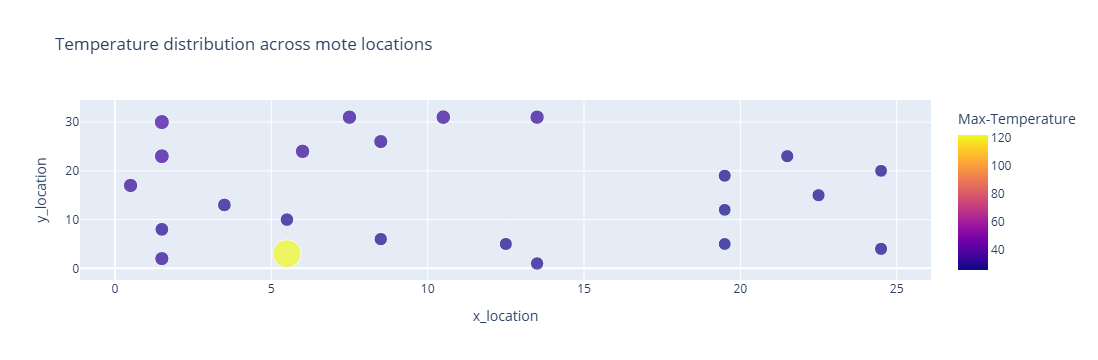

In [27]:
# Merge time_avg_df with mote_locs on 'moteid'
merged_df = pd.merge(Motes_max_temp_df, mote_locs, on='moteid', how='left')
#print(merged_df.head())

# Step 2: Basic scatter plot to analyze temperature vs locations
fig = px.scatter(
    merged_df,
    x='x_location',
    y='y_location',
    size='Max-Temperature',  # bubble size represents temperature
    color='Max-Temperature', # color represents temperature
    hover_data=['moteid', 'Max-Temperature'],
    title='Temperature distribution across mote locations'
)
fig.show()

<b> Insight(s): </b> From the plot above, it is evident that Mote 15 recorded an abnormally high temperature (maximum temperature) compared to the other motes which have recorded temperatures between 25 and 35. This may be due to several reasons, such as a sensor malfunction or if Mote15 were placed near an equipment generating heating or direct sunlight. Mote 15's high temperature is most likely due to its placement within the LAB zone, possibly near heat-generating equipment or exposed to direct sunlight. Thus, Mote 15's high reading could be due to a localized environmental effect on one or more days. Refer to the section [Mapping-Motes-to-Floor-Plan-Zones](#Mapping-Motes-to-Floor-Plan-Zones).


## How do temperature and humidity correlate across different motes or locations over time?

As GridDB TQL doesn't allow multiple aggregations within the same query, we create separate functions using Python to get results for average humidity and average temperature. We then merge the two dataframes with the mote locations dataframe based on the moteid column. 

In [29]:
def get_avg_temp_for_motes(mote_id, start_time, end_time):
    query = f"""
        SELECT AVG(temperature)
        WHERE
        temperature > 25
        AND moteid = {mote_id}
        AND TIMESTAMP('{start_time}') <= timestamp
        AND timestamp < TIMESTAMP('{end_time}')
    """
    df, elapsed = run_tql(query, container="sensor_data")
    if not df.empty:
        df["moteid"] = mote_id
    return df

In [30]:
motes = [1,2,3,4,5,6,8,10,12,13,14,15,16,17,18,19,20,22,23,24,26,27,28,30]
start_time = "2004-03-01T00:00:00Z"
end_time = "2004-03-04T00:00:00Z"

results = []
for mote in motes:
    df = get_avg_temp_for_motes(mote, start_time, end_time)
    if not df.empty:
        results.append(df)

# Combining results
Motes_avg_temp_df = pd.concat(results, ignore_index=True)

Query ran in 0.776s | 1 rows returned
Query ran in 0.711s | 1 rows returned
Query ran in 0.723s | 1 rows returned
Query ran in 0.721s | 1 rows returned
Query ran in 0.748s | 0 rows returned
Query ran in 0.768s | 1 rows returned
Query ran in 0.722s | 1 rows returned
Query ran in 0.759s | 1 rows returned
Query ran in 0.746s | 1 rows returned
Query ran in 0.741s | 1 rows returned
Query ran in 0.745s | 1 rows returned
Query ran in 0.753s | 1 rows returned
Query ran in 0.753s | 1 rows returned
Query ran in 0.712s | 1 rows returned
Query ran in 0.728s | 1 rows returned
Query ran in 0.714s | 1 rows returned
Query ran in 0.749s | 1 rows returned
Query ran in 0.758s | 1 rows returned
Query ran in 0.711s | 1 rows returned
Query ran in 0.719s | 1 rows returned
Query ran in 0.753s | 1 rows returned
Query ran in 0.755s | 1 rows returned
Query ran in 0.746s | 1 rows returned
Query ran in 0.719s | 1 rows returned


In [31]:
def get_avg_humidity_for_motes(mote_id, start_time, end_time):
    query = f"""
        SELECT AVG(humidity)
        WHERE
        temperature > 25
        AND moteid = {mote_id}
        AND TIMESTAMP('{start_time}') <= timestamp
        AND timestamp < TIMESTAMP('{end_time}')
    """
    df, elapsed = run_tql(query, container="sensor_data")
    if not df.empty:
        df["moteid"] = mote_id
    return df

In [32]:
motes = [1,2,3,4,5,6,8,10,12,13,14,15,16,17,18,19,20,22,23,24,26,27,28,30]
start_time = "2004-03-01T00:00:00Z"
end_time = "2004-03-04T00:00:00Z"

results = []
for mote in motes:
    df = get_avg_humidity_for_motes(mote, start_time, end_time)
    if not df.empty:
        results.append(df)

# Combining results
Motes_avg_humidity = pd.concat(results, ignore_index=True)

Query ran in 0.735s | 1 rows returned
Query ran in 0.743s | 1 rows returned
Query ran in 0.748s | 1 rows returned
Query ran in 0.739s | 1 rows returned
Query ran in 0.743s | 0 rows returned
Query ran in 0.697s | 1 rows returned
Query ran in 0.752s | 1 rows returned
Query ran in 0.724s | 1 rows returned
Query ran in 0.757s | 1 rows returned
Query ran in 0.718s | 1 rows returned
Query ran in 0.746s | 1 rows returned
Query ran in 0.722s | 1 rows returned
Query ran in 0.729s | 1 rows returned
Query ran in 0.707s | 1 rows returned
Query ran in 0.735s | 1 rows returned
Query ran in 0.716s | 1 rows returned
Query ran in 0.719s | 1 rows returned
Query ran in 0.749s | 1 rows returned
Query ran in 0.773s | 1 rows returned
Query ran in 0.717s | 1 rows returned
Query ran in 0.719s | 1 rows returned
Query ran in 0.706s | 1 rows returned
Query ran in 0.739s | 1 rows returned
Query ran in 0.743s | 1 rows returned


In [34]:
merged_sub_df = pd.merge(Motes_avg_humidity, Motes_avg_temp_df, on='moteid', how='left')
merged_df = pd.merge(merged_sub_df, mote_locs , on='moteid', how='left')
merged_df.head()

,Avg-Humidity,moteid,Avg-Temperature,x_location,y_location
0,30.582711,1,25.569478,21.5,23
1,25.928965,2,25.167988,24.5,20
2,31.203430,3,25.429288,19.5,19
3,32.662568,4,25.948840,22.5,15
4,36.655477,6,25.068946,19.5,12


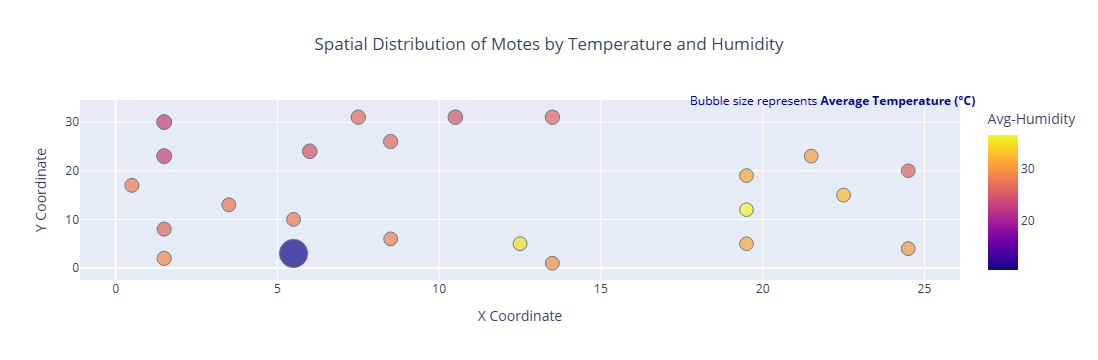

In [35]:
fig = px.scatter(
    merged_df,
    x="x_location",
    y="y_location",
    size="Avg-Temperature",       # Bubble size = temperature
    color="Avg-Humidity",         # Color = humidity
    hover_name="moteid",
    hover_data={"Avg-Temperature": True, "Avg-Humidity": True, "x_location": False, "y_location": False},
    title="Spatial Distribution of Motes by Temperature and Humidity",
    labels={"x_location": "X Coordinate", "y_location": "Y Coordinate", "Avg_Temperature": "Avg Temp (°C)", "Avg_Humidity": "Avg Humidity (%)"}
)

# Add visual polish
fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

# Add an annotation explaining the bubble size
fig.add_annotation(
    text="Bubble size represents <b>Average Temperature (°C)</b>",
    xref="paper", yref="paper",
    x=1.02, y=1.05,
    showarrow=False,
    font=dict(size=12, color="darkblue")
)

# Center the title
fig.update_layout(
    title_x=0.5,
    legend_title_text="Average Humidity (%)"
)

fig.show()

<b> Insight(s): </b> While analyzing the Spatial Distribution, we see that Mote15 is an anomaly with a temperature of 107 and a humidity of 10.46. In other words, the average temperature of the mote is way higher than the average temperature recorded by the remaining motes. But, the average humidity of Mote 15 is way lower than the average humidity of the other motes. Mote 15 is placed in the LAB zone, as per the [Mapping-floor-plan](#Mapping-Motes-to-Floor-Plan-Zones). Its extreme temperature and low humidity suggest it may be positioned near heat-emitting equipment or placed in a poorly ventilated area or an enclosed space. Alternatively, the mote may be experiencing a sensor malfunction.


### At what times do voltage readings spike or drop unexpectedly?

In [38]:
start_date = datetime(2004, 3, 1)
end_date = datetime(2004, 4, 1)  # exclusive

motes = [1,2,3,4,5,6,8,10,12,13,14,15,16,17,18,19,20,22,23,24,26,27,28,30]

results = []

# Loop over each day and each mote
current_date = start_date
while current_date < end_date:
    next_date = current_date + timedelta(days=1)
    for mote_id in motes:
        query = f"""
        SELECT TIME_AVG(voltage)
        WHERE moteid = {mote_id}
        AND TIMESTAMP('{current_date.isoformat()}Z') <= timestamp
        AND timestamp < TIMESTAMP('{next_date.isoformat()}Z')
        """
        df, elapsed = run_tql(query, container="sensor_data")
        if not df.empty:
            df["moteid"] = mote_id
            df["date"] = current_date.date()  # use date as timestamp
            results.append(df)
    current_date = next_date

# Combine all daily averages into one dataframe
Motes_avg_voltage = pd.concat(results, ignore_index=True)

# Rename the aggregation column
Motes_avg_voltage.rename(columns={"aggregationResult": "avg_voltage"}, inplace=True)

print(Motes_avg_voltage.head())

Query ran in 1.252s | 1 rows returned
Query ran in 0.885s | 1 rows returned
Query ran in 0.903s | 1 rows returned
Query ran in 0.811s | 1 rows returned
Query ran in 0.813s | 0 rows returned
Query ran in 0.821s | 1 rows returned
Query ran in 0.784s | 1 rows returned
Query ran in 0.740s | 1 rows returned
Query ran in 0.825s | 1 rows returned
Query ran in 0.786s | 1 rows returned
Query ran in 0.753s | 1 rows returned
Query ran in 0.826s | 1 rows returned
Query ran in 0.757s | 1 rows returned
Query ran in 0.838s | 1 rows returned
Query ran in 0.845s | 1 rows returned
Query ran in 0.781s | 1 rows returned
Query ran in 0.940s | 1 rows returned
Query ran in 0.741s | 1 rows returned
Query ran in 0.917s | 1 rows returned
Query ran in 0.783s | 1 rows returned
Query ran in 0.830s | 1 rows returned
Query ran in 0.738s | 1 rows returned
Query ran in 0.793s | 0 rows returned
Query ran in 0.820s | 1 rows returned
Query ran in 0.816s | 1 rows returned
Query ran in 0.812s | 1 rows returned
Query ran in

In [39]:
Motes_avg_voltage.head()

,Time_avg-Voltage,moteid,date
0,2.687923,1,2004-03-01
1,2.662244,2,2004-03-01
2,2.689153,3,2004-03-01
3,2.654764,4,2004-03-01
4,2.631788,6,2004-03-01


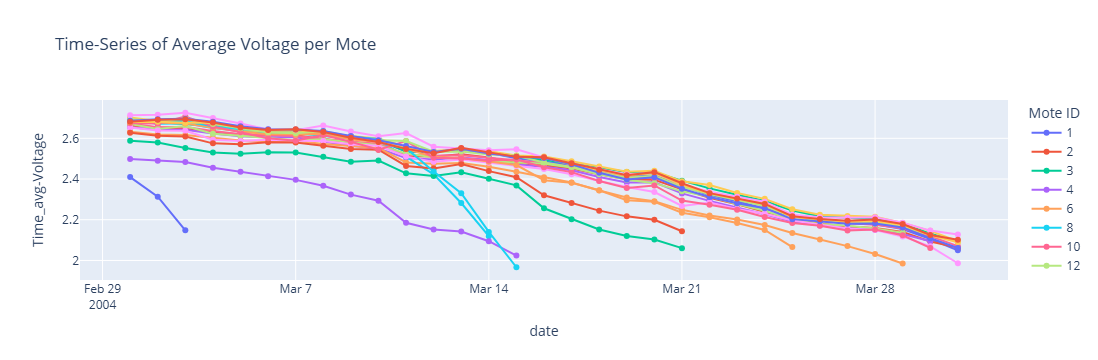

In [40]:
fig = px.line(Motes_avg_voltage,
              x='date',
              y='Time_avg-Voltage',
              color='moteid',  # separate lines per mote
              title='Time-Series of Average Voltage per Mote',
              labels={'time_avg_voltage': 'Voltage', 'timestamp': 'Time', 'moteid': 'Mote ID'},
              markers=True)

fig.show()

<b> Insight(s): </b> Looking at the overall trend, we see that for most motes, the average voltage is gradually decreasing over time. This suggests that either the motes' batteries are discharging slowly or the voltage supply is dropping over time. When it comes to specific trends, Motes 8, 15, 16, 17, 18, and 20 show a sharp decline in voltage around mid-March. Moreover, their average voltages are not consistent with those of the other motes. The sharp voltage drop could indicate a sensor malfunction, temporary power loss, or disconnection.

## Concluding Remarks

In conclusion, GridDB's TimeSeries container proved to be highly efficient in handling the Intel Lab dataset, having over 2 Million rows. Using TQL, we were able to store, query, and retrieve large volumes of sensor data within seconds, enabling faster analysis. The query execution times are a testament to the fact that GridDB's TimeSeries containers are optimized for large datasets. Hence, GridDB is suitable for IoT applications as it can handle big data with impressive speed and reliability. By combining GridDB’s timeseries capabilities with Python, we were able to dive into the analysis right away, as query execution was never a bottleneck. For teams working with IoT, high-frequency monitoring and real-time analytics, GridDB Cloud offers a powerful foundation for building highly responsive applications. Check out the official <a href = "https://griddb.net/en/blog/griddb-cloud-quick-start-guide/"> GridDB Cloud </a> page to learn more. 